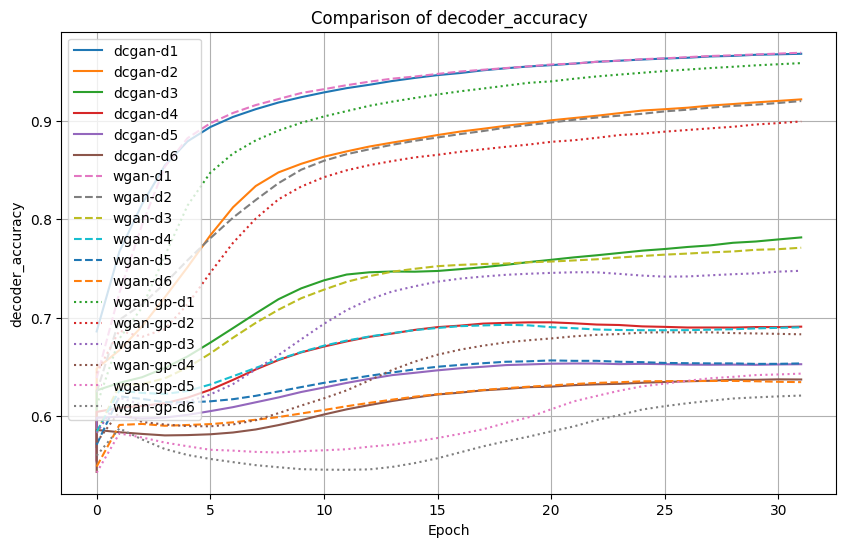

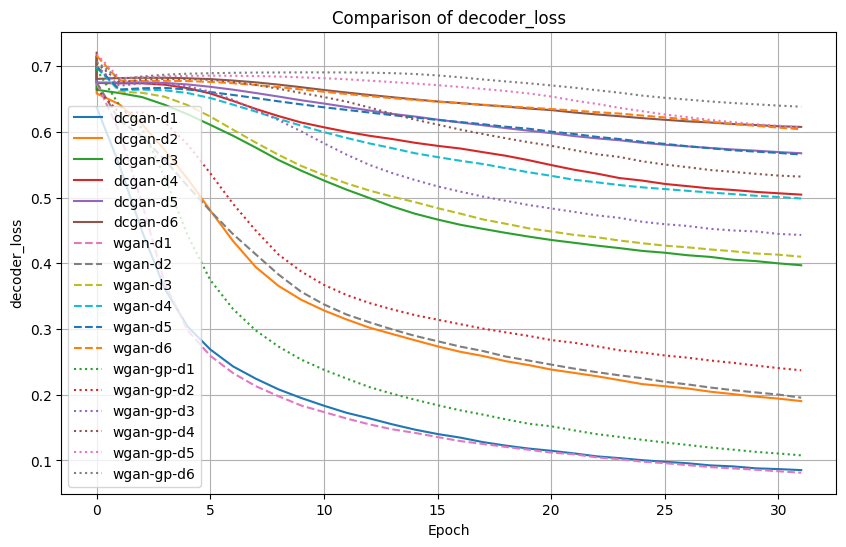

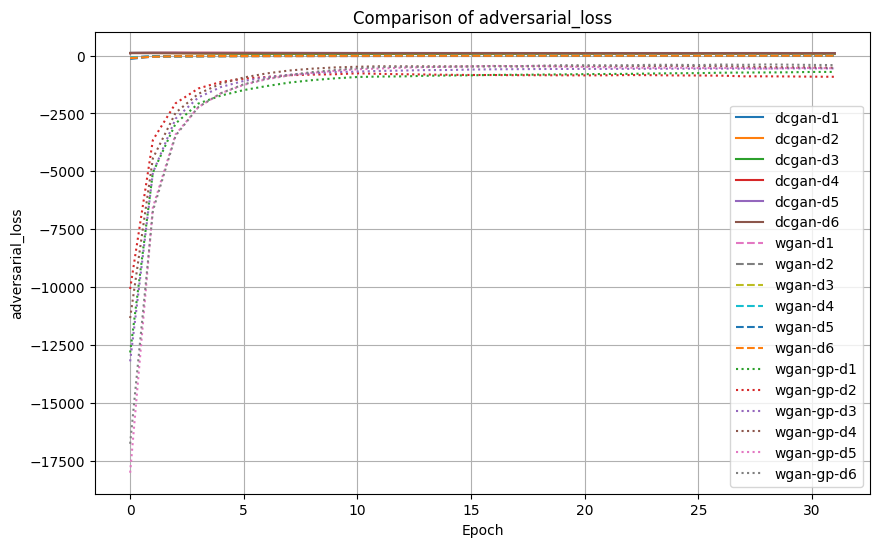

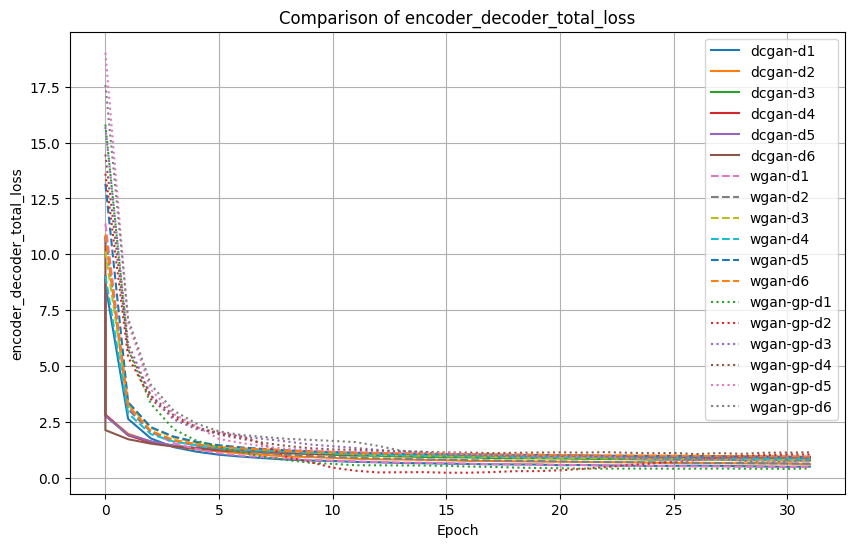

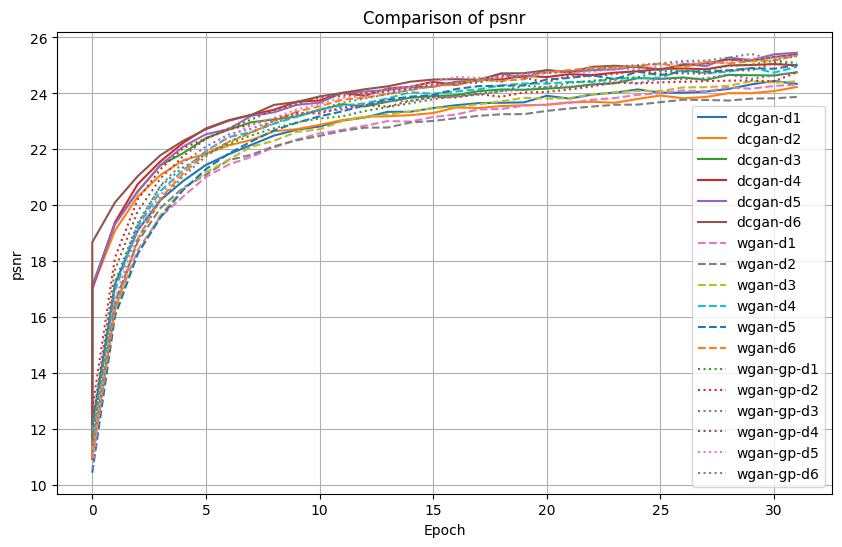

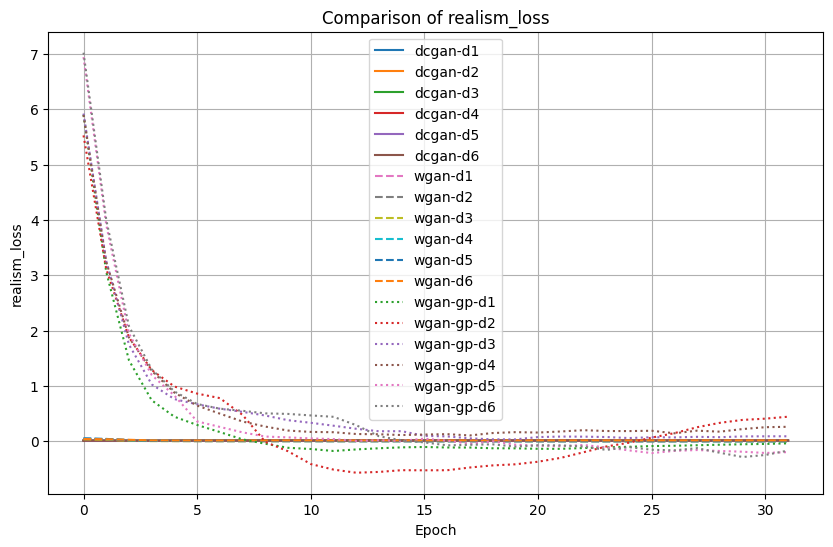

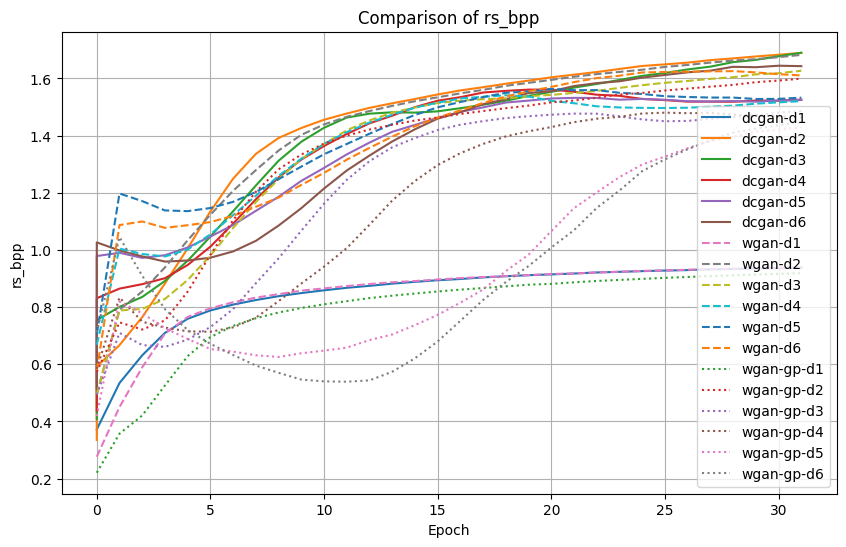

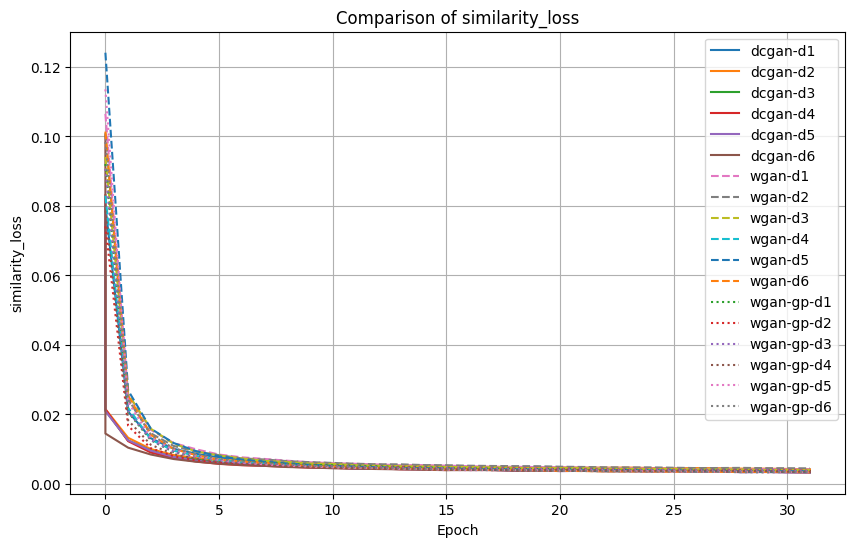

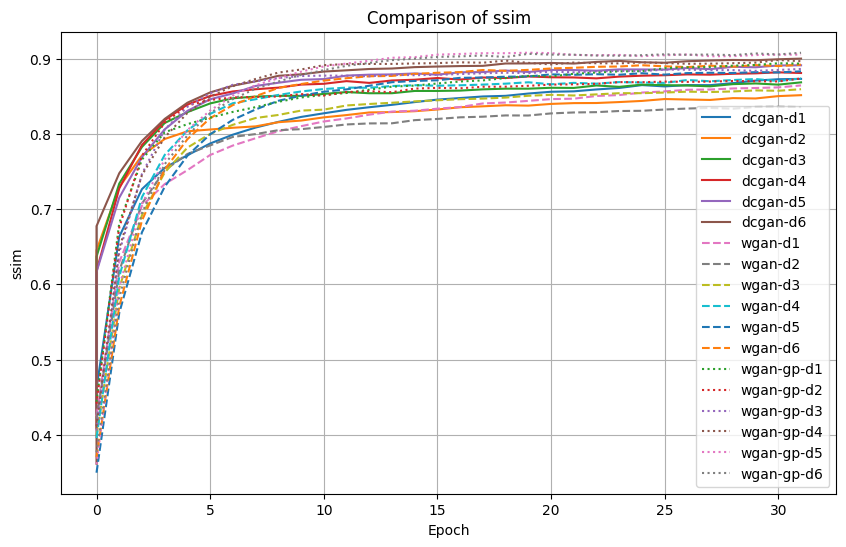

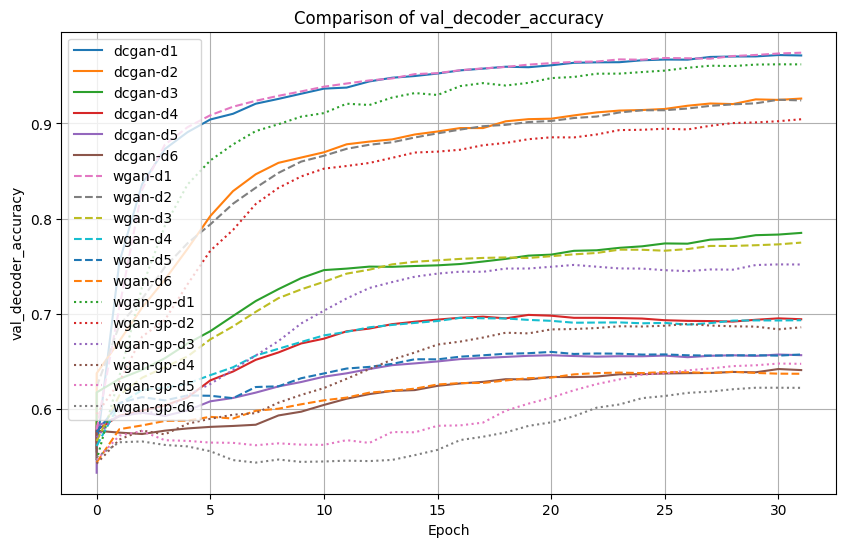

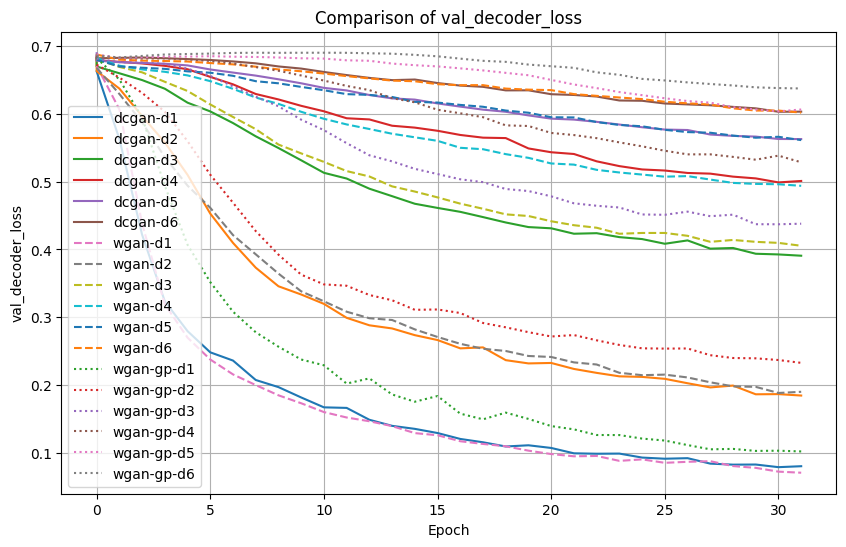

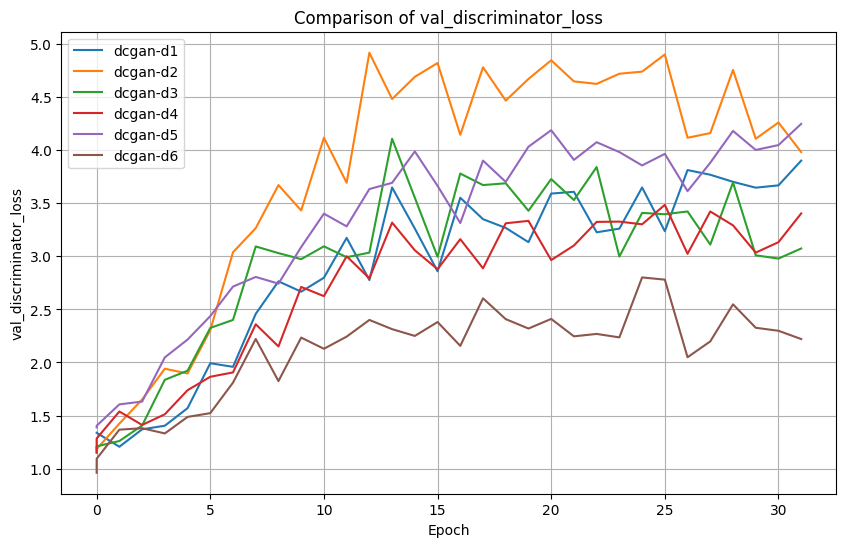

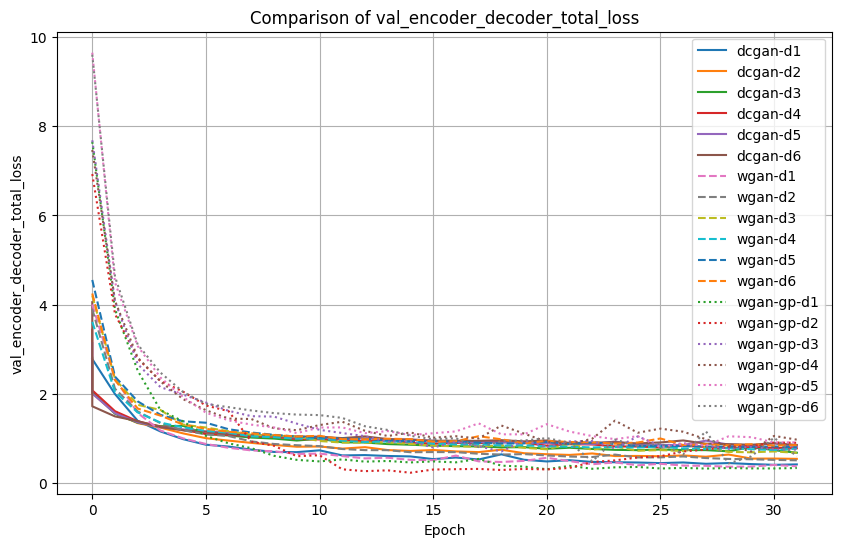

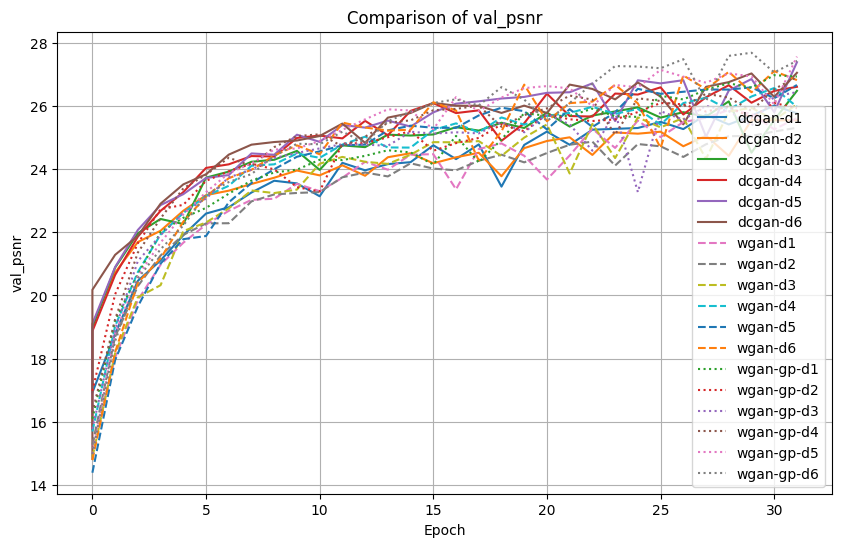

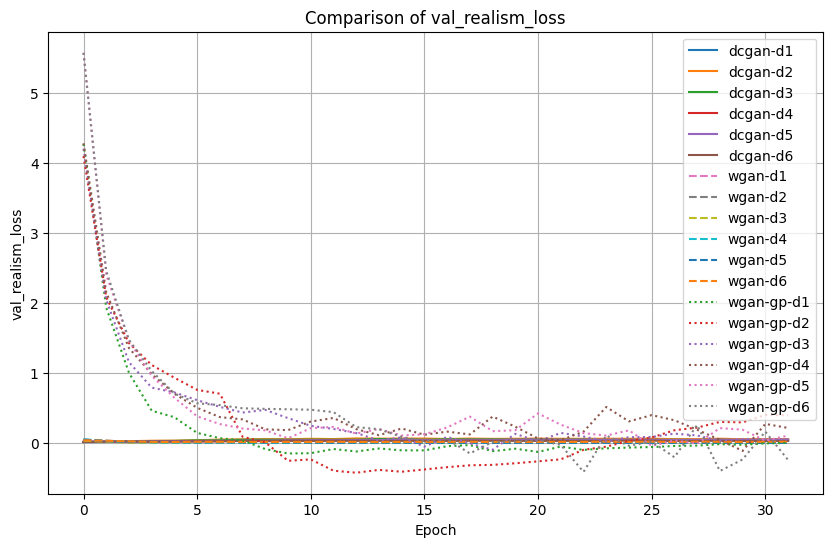

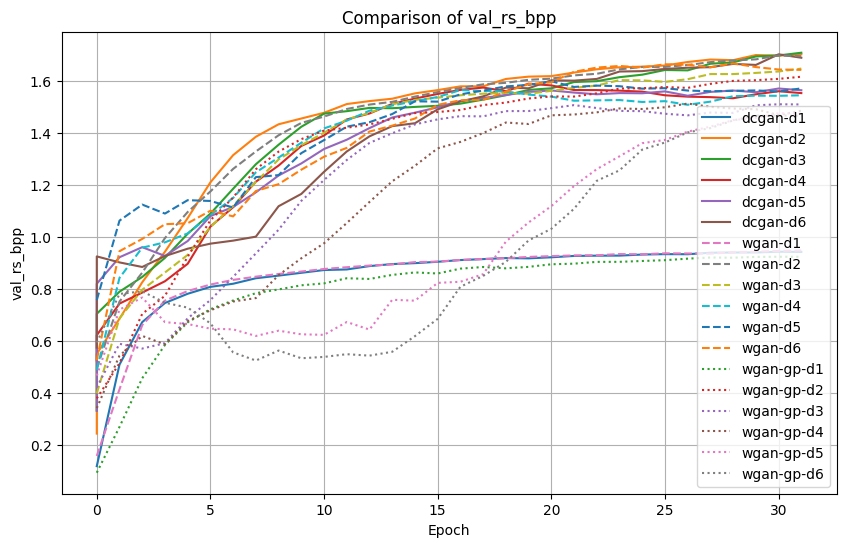

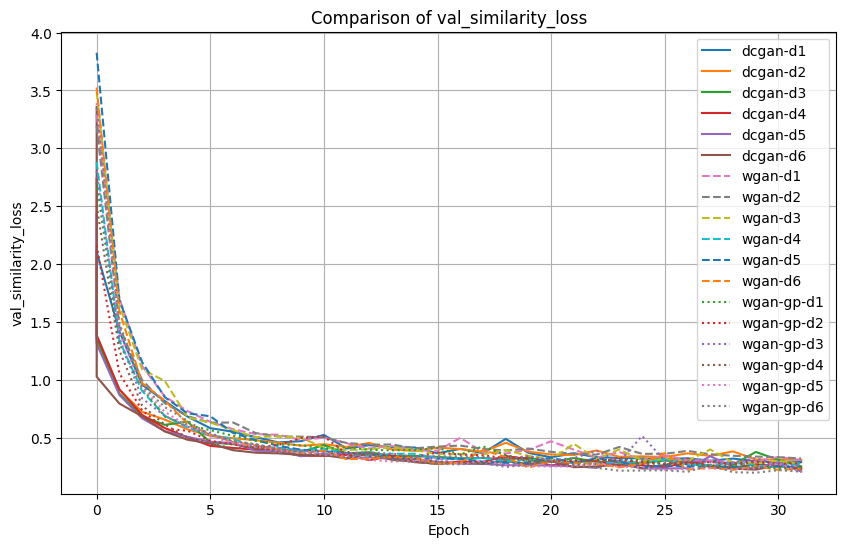

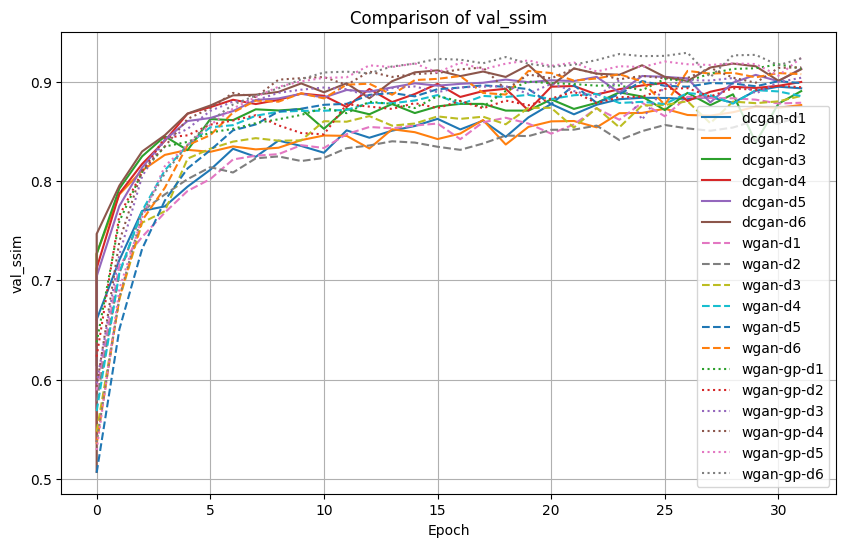

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

models = ["dcgan", "wgan", "wgan-gp"]
dirs = ["d1", "d2", "d3", "d4", "d5", "d6"]
line_styles = {"dcgan": "-", "wgan": "--", "wgan-gp": ":"}  # Різні стилі ліній

# Читаємо всі CSV файли у вкладених директоріях
def load_data():
    data = {}
    for model in models:
        for d in dirs:
            file_path = os.path.join(model, d, "SteganoGAN.csv")
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                
                # Об'єднуємо назви loss-функцій
                if "discriminator_loss" in df.columns:
                    df = df.rename(columns={"discriminator_loss": "adversarial_loss"})
                if "critic_loss" in df.columns:
                    df = df.rename(columns={"critic_loss": "adversarial_loss"})

                data[(model, d)] = df
    return data

data = load_data()

# Отримуємо список метрик (з урахуванням перейменування)
metrics = list(data[next(iter(data))].columns[1:])  # Пропускаємо "epoch"

# Будуємо графіки
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.title(f"Comparison of {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    
    for model in models:
        for d in dirs:
            if (model, d) in data and metric in data[(model, d)].columns:
                df = data[(model, d)]
                plt.plot(df["epoch"], df[metric], label=f"{model}-{d}", linestyle=line_styles[model])
    
    plt.legend()
    plt.grid()
    plt.show()


In [11]:
import pandas as pd

# Фільтруємо лише ті метрики, які не є валідаційними
def is_validation_metric(metric_name):
    return "val_" in metric_name

# Отримуємо список усіх метрик (без валідаційних)
all_metrics = [m for m in metrics if not is_validation_metric(m)]

# Створюємо таблицю
final_results = []

for model in models:
    for d in dirs:
        if (model, d) in data:
            df = data[(model, d)]
            last_epoch_values = df.iloc[-1]  # Останній рядок
            result = {"model": model, "dir": d, "epoch": last_epoch_values["epoch"]}
            for metric in all_metrics:
                if metric in last_epoch_values:
                    result[metric] = last_epoch_values[metric]
            final_results.append(result)

# Конвертуємо в DataFrame
df_results = pd.DataFrame(final_results)

# Виводимо таблицю
print(df_results)

# Зберігаємо в CSV
df_results.to_csv("final_results.csv", index=False)


      model dir  epoch  decoder_accuracy  decoder_loss  adversarial_loss  \
0     dcgan  d1   31.0          0.968727      0.085224          0.830760   
1     dcgan  d2   31.0          0.922260      0.190321          0.737311   
2     dcgan  d3   31.0          0.781632      0.397130          0.848529   
3     dcgan  d4   31.0          0.690720      0.504690          0.998420   
4     dcgan  d5   31.0          0.652448      0.567733          1.077514   
5     dcgan  d6   31.0          0.636902      0.607778          1.032195   
6      wgan  d1   31.0          0.969792      0.081233         -0.150954   
7      wgan  d2   31.0          0.920559      0.195518         -0.125453   
8      wgan  d3   31.0          0.771116      0.410082         -0.127780   
9      wgan  d4   31.0          0.690042      0.498790         -0.101366   
10     wgan  d5   31.0          0.653266      0.565739         -0.106632   
11     wgan  d6   31.0          0.634204      0.604149         -0.086795   
12  wgan-gp 

In [12]:
import pandas as pd

# Завантажуємо CSV-файл
df = pd.read_csv("final_results.csv")

# Вибираємо лише потрібні колонки
selected_columns = ["model", "dir", "decoder_accuracy", "rs_bpp", "psnr", "ssim", ]
df_selected = df[selected_columns]

# Округлюємо значення до 0.01
df_selected = df_selected.round(2)

# Виводимо результат
print(df_selected)

# Зберігаємо в новий файл
df_selected.to_csv("filtered_results.csv", index=False)


      model dir  decoder_accuracy  rs_bpp   psnr  ssim
0     dcgan  d1              0.97    0.94  24.34  0.87
1     dcgan  d2              0.92    1.69  24.23  0.85
2     dcgan  d3              0.78    1.69  24.75  0.87
3     dcgan  d4              0.69    1.53  25.00  0.88
4     dcgan  d5              0.65    1.52  25.45  0.89
5     dcgan  d6              0.64    1.64  25.39  0.90
6      wgan  d1              0.97    0.94  24.32  0.86
7      wgan  d2              0.92    1.68  23.87  0.84
8      wgan  d3              0.77    1.63  24.43  0.86
9      wgan  d4              0.69    1.52  24.95  0.87
10     wgan  d5              0.65    1.53  25.01  0.88
11     wgan  d6              0.63    1.61  25.35  0.89
12  wgan-gp  d1              0.96    0.92  25.09  0.89
13  wgan-gp  d2              0.90    1.60  24.76  0.87
14  wgan-gp  d3              0.75    1.49  24.76  0.89
15  wgan-gp  d4              0.68    1.46  25.01  0.90
16  wgan-gp  d5              0.64    1.43  25.37  0.91
17  wgan-g